# トロッコ問題シミュレーション

## 問題
人が $n$ 人います。みんなで同時に、コインを投げて「表」か「裏」を決めます。

- 多い方のグループだけが残ります
- 少ない方はいなくなります
- もし同じ人数なら、全員そのまま残ります

これを何回もくり返します。さいごに残る人数は、何人になるでしょうか？

In [29]:
# 1回のシミュレーション（n人からスタート）
# ルール：多数派が残る、同数なら全員残って次ラウンドへ
# 最終的に残る人数と、かかったラウンド数を返す
function simulate_once(n::Int)
    rounds = 0
    current = n
    while current > 2
        count_heads = sum(rand(0:1, current))
        count_tails = current - count_heads
        rounds += 1
        if count_heads > count_tails
            current = count_heads       # 表が多数派 → 裏を除外
        elseif count_tails > count_heads
            current = count_tails       # 裏が多数派 → 表を除外
        end
        # 同数（タイ）のときは current そのまま → 次のラウンドへ
    end
    return current, rounds
end

# テスト
for n in [3, 5, 10, 20]
    final, rounds = simulate_once(n)
    println("n=$n → 最終人数: $final 人（$rounds ラウンド）")
end

n=3 → 最終人数: 2 人（1 ラウンド）
n=5 → 最終人数: 2 人（2 ラウンド）
n=10 → 最終人数: 2 人（10 ラウンド）
n=20 → 最終人数: 2 人（9 ラウンド）


In [32]:
using Statistics

# 複数回シミュレーションして統計を取る
function simulate_many(n::Int, trials::Int=10000)
    final_counts = Int[]
    round_counts = Int[]
    for _ in 1:trials
        fc, rc = simulate_once(n)
        push!(final_counts, fc)
        push!(round_counts, rc)
    end
    return final_counts, round_counts
end

n = 10
trials = 10000
final_counts, round_counts = simulate_many(n, trials)

println("n=$n, 試行回数=$trials")
println("最終人数の平均: ", round(mean(final_counts), digits=3))
println("ラウンド数の平均: ", round(mean(round_counts), digits=3))
println("ラウンド数の最大: ", maximum(round_counts))

n=10, 試行回数=10000
最終人数の平均: 2.0
ラウンド数の平均: 6.069
ラウンド数の最大: 19


In [33]:
# n を変えてラウンド数の期待値を調べる（最終人数は n≥2 なら常に 2）
ns = 2:2:30
trials = 20000

println("n  | ラウンド数の平均 | ラウンド数の最大")
println("---|-----------------|----------------")
for n in ns
    _, rc = simulate_many(n, trials)
    avg_rounds = round(mean(rc), digits=2)
    max_rounds = maximum(rc)
    println("$n  | $avg_rounds             | $max_rounds")
end

n  | ラウンド数の平均 | ラウンド数の最大
---|-----------------|----------------
2  | 0.0             | 0
4  | 3.34             | 18
6  | 4.77             | 18
8  | 5.12             | 18
10  | 6.04             | 20
12  | 6.06             | 19
14  | 6.51             | 20
16  | 6.72             | 22
18  | 7.19             | 22
20  | 7.17             | 23
22  | 7.34             | 27
24  | 7.48             | 23
26  | 7.72             | 20
28  | 7.81             | 25
30  | 8.02             | 25


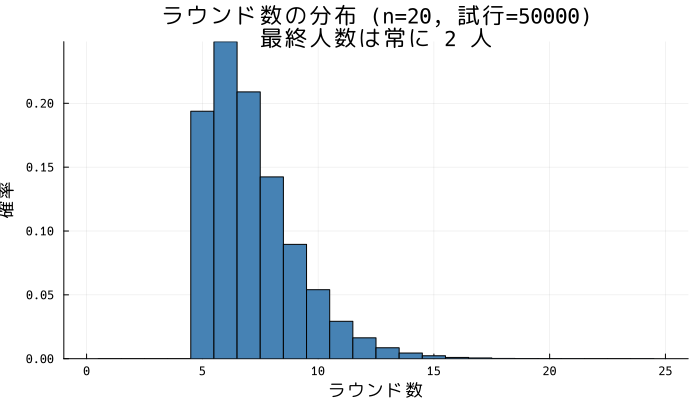

In [36]:
using Plots,PlotsGRBackendFontJaEmoji

# ラウンド数の分布を可視化（n=20の場合）
n = 20
trials = 50000
_, round_counts = simulate_many(n, trials)

histogram(round_counts,
    bins=range(0.5, maximum(round_counts)+0.5, step=1),
    xlabel="ラウンド数",
    ylabel="確率",
    title="ラウンド数の分布 (n=$n, 試行=$trials)\n最終人数は常に 2 人",
    legend=false,
    color=:steelblue,
    normalize=:probability,
    size=(700, 400))

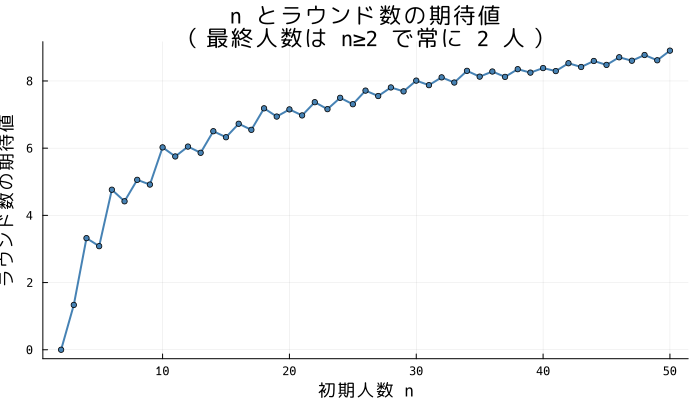

In [24]:
# n とラウンド数の期待値の関係をグラフ化
ns = 2:50
trials = 10000

avg_rounds_list = Float64[]

for n in ns
    _, rc = simulate_many(n, trials)
    push!(avg_rounds_list, mean(rc))
end

plot(ns, avg_rounds_list,
    xlabel="初期人数 n",
    ylabel="ラウンド数の期待値",
    title="n とラウンド数の期待値\n（最終人数は n≥2 で常に 2 人）",
    legend=false,
    lw=2,
    color=:steelblue,
    marker=:circle,
    markersize=3,
    size=(700, 400))

フィット結果：E[ラウンド数] ≈ 1.42 × log₂(n) + 0.715


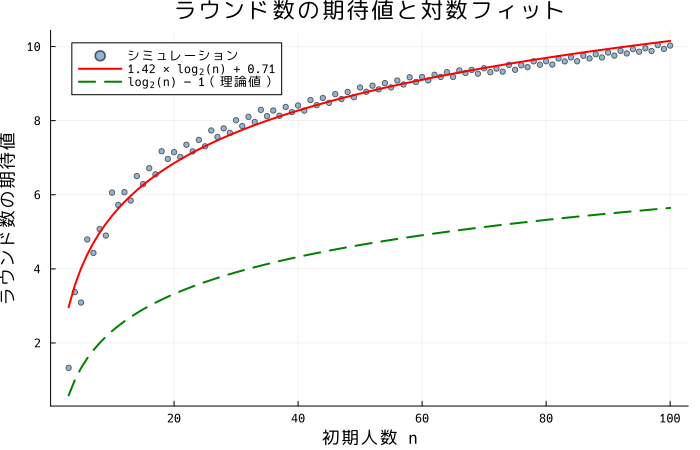

In [37]:
# 対数関数へのフィッティング
# 理論：各ラウンドで約 n/2 人が残る → t ラウンド後に n/2^t 人
# n/2^t = 2 を解くと t = log₂(n) - 1 ≈ log₂(n)
# タイのラウンドは人数が減らないため、定数項 b でその影響を補正

ns_fit = collect(3:100)
trials_fit = 20000

avg_rounds_fit = Float64[]
for n in ns_fit
    _, rc = simulate_many(n, trials_fit)
    push!(avg_rounds_fit, mean(rc))
end

# log₂(n) にフィット：E[rounds] ≈ a * log₂(n) + b
log2_ns = log2.(ns_fit)
A = hcat(log2_ns, ones(length(log2_ns)))   # 設計行列
coeffs = A \ avg_rounds_fit                  # 最小二乗法
a, b = coeffs
println("フィット結果：E[ラウンド数] ≈ $(round(a, digits=3)) × log₂(n) + $(round(b, digits=3))")

using Plots
p = scatter(ns_fit, avg_rounds_fit,
    label="シミュレーション",
    xlabel="初期人数 n",
    ylabel="ラウンド数の期待値",
    title="ラウンド数の期待値と対数フィット",
    markersize=3, color=:steelblue, alpha=0.6)

plot!(p, ns_fit, a .* log2_ns .+ b,
    label="$(round(a,digits=2)) × log₂(n) + $(round(b,digits=2))",
    lw=2, color=:red)

plot!(p, ns_fit, log2.(ns_fit) .- 1,
    label="log₂(n) − 1（理論値）",
    lw=2, color=:green, linestyle=:dash,
    size=(700, 450))

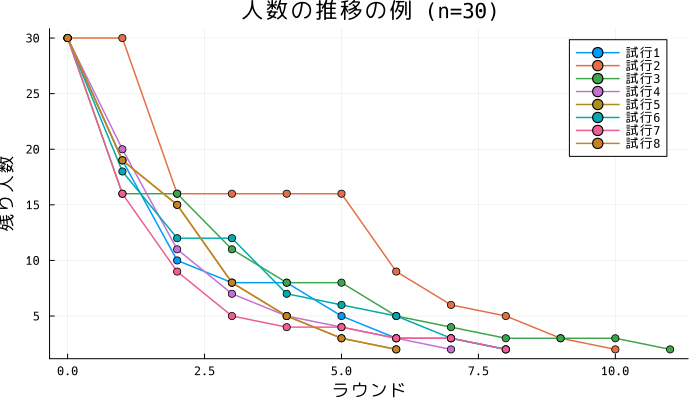

In [25]:
# 1試行の人数推移を可視化
function simulate_trace(n::Int)
    history = [n]
    current = n
    while current > 2
        count_heads = sum(rand(0:1, current))
        count_tails = current - count_heads
        if count_heads > count_tails
            current = count_heads
        elseif count_tails > count_heads
            current = count_tails
        end
        push!(history, current)
    end
    return history
end

# 8回分の軌跡を重ね書き
n = 30
plt = plot(title="人数の推移の例 (n=$n)",
           xlabel="ラウンド", ylabel="残り人数",
           legend=:topright, size=(700, 400))

for i in 1:8
    trace = simulate_trace(n)
    plot!(plt, 0:length(trace)-1, trace, label="試行$i", lw=1.5, marker=:circle, markersize=4)
end

plt